In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Read the CSV file
vac = pd.read_csv('/Users/xylu/Desktop/Data/machine_local/vacuum_D11/2026-01-30T13_37_05.960Z.csv')

# Assuming the first column is time and the rest are channels
time_col = vac.columns[0]
channel_cols = vac.columns[1:]

# Convert time column to datetime
vac[time_col] = pd.to_datetime(vac[time_col])

# Check for NaN values
print(f"\nNaN values per column:")
print(vac.isna().sum())

# Find the L21 column (reference channel)
l21_col = [col for col in channel_cols if '_L21:' in col][0]
print(f"\nReference channel: {l21_col}")

# Calculate ratios relative to L21
ratio_data = {}
for channel in channel_cols:
    ratio_data[channel] = vac[channel] / vac[l21_col]
    print(f"{channel} / {l21_col}")

# Calculate baseline (average of first 100 points or 10% of data, whichever is smaller)
n_baseline = min(100, len(vac) // 10)
print(f"\nUsing first {n_baseline} points for baseline averaging")

baseline_values = {}
normalized_data = {}
for channel in channel_cols:
    baseline_values[channel] = vac[channel].iloc[:n_baseline].mean()
    normalized_data[channel] = vac[channel] / baseline_values[channel]
    print(f"{channel} baseline: {baseline_values[channel]:.2e}")

# Create three subplots
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 14))

# Plot 1: Absolute pressure values
for channel in channel_cols:
    ax1.plot(vac[time_col], vac[channel], linewidth=1, label=channel)

ax1.set_xlabel('Time')
ax1.set_ylabel('Pressure')
ax1.legend(loc='upper left', fontsize=8)
ax1.grid(True, alpha=0.3)
ax1.set_title('Absolute Pressure')

# Plot 2: Ratios relative to L21
for channel in channel_cols:
    if channel != l21_col:  # Don't plot L21/L21 (which is always 1)
        ax2.plot(vac[time_col], ratio_data[channel], linewidth=1, label=f"{channel}/{l21_col}")

ax2.set_xlabel('Time')
ax2.set_ylabel('Ratio relative to L21')
ax2.legend(loc='upper left', fontsize=8)
ax2.grid(True, alpha=0.3)
ax2.set_title('Pressure Ratios (relative to L21)')

# Plot 3: Normalized to baseline (beginning values)
for channel in channel_cols:
    ax3.plot(vac[time_col], normalized_data[channel], linewidth=1, label=channel)

ax3.set_xlabel('Time')
ax3.set_ylabel('Normalized Pressure (relative to baseline)')
ax3.legend(loc='upper left', fontsize=8)
ax3.grid(True, alpha=0.3)
ax3.set_title(f'Pressure Normalized to Baseline (average of first {n_baseline} points)')
ax3.axhline(y=1, color='k', linestyle='--', linewidth=0.5, alpha=0.5)

plt.tight_layout()
plt.show()


NaN values per column:
Timestamp                 0
VALCCG:D11_L21:PRES    2755
VALCCG:D11_L20:PRES    2755
VALCCG:D11_L22:PRES    2755
VALCCG:D11_L23:PRES    2755
VALCCG:D11_L24:PRES    2755
VALCCG:D11_L25:PRES    2755
VALCCG:D11_L19:PRES    2755
VALCCG:D11_L18:PRES    3881
VALCCG:D11_L17:PRES    2755
VALCCG:D11_L16:PRES    4157
VALCCG:D11_L15:PRES    4569
VALCCG:D11_L14:PRES    4216
VALCCG:D11_L13:PRES    4370
VALCCG:D11_L12:PRES    4569
VALCCG:D11_L11:PRES    4365
VALCCG:D11_L10:PRES    3031
VALCCG:D11_L09:PRES    4519
VALCCG:D11_L08:PRES    4322
VALCCG:D11_L07:PRES    4351
VALCCG:D11_L06:PRES    4252
VALCCG:D11_L05:PRES    4302
VALCCG:D11_L04:PRES    4367
VALCCG:D11_L03:PRES    4324
VALCCG:D11_L02:PRES    4272
VALCCG:D11_L01:PRES    4328
dtype: int64

Reference channel: VALCCG:D11_L21:PRES
VALCCG:D11_L21:PRES / VALCCG:D11_L21:PRES
VALCCG:D11_L20:PRES / VALCCG:D11_L21:PRES
VALCCG:D11_L22:PRES / VALCCG:D11_L21:PRES
VALCCG:D11_L23:PRES / VALCCG:D11_L21:PRES
VALCCG:D11_L24:PRES / VALCC

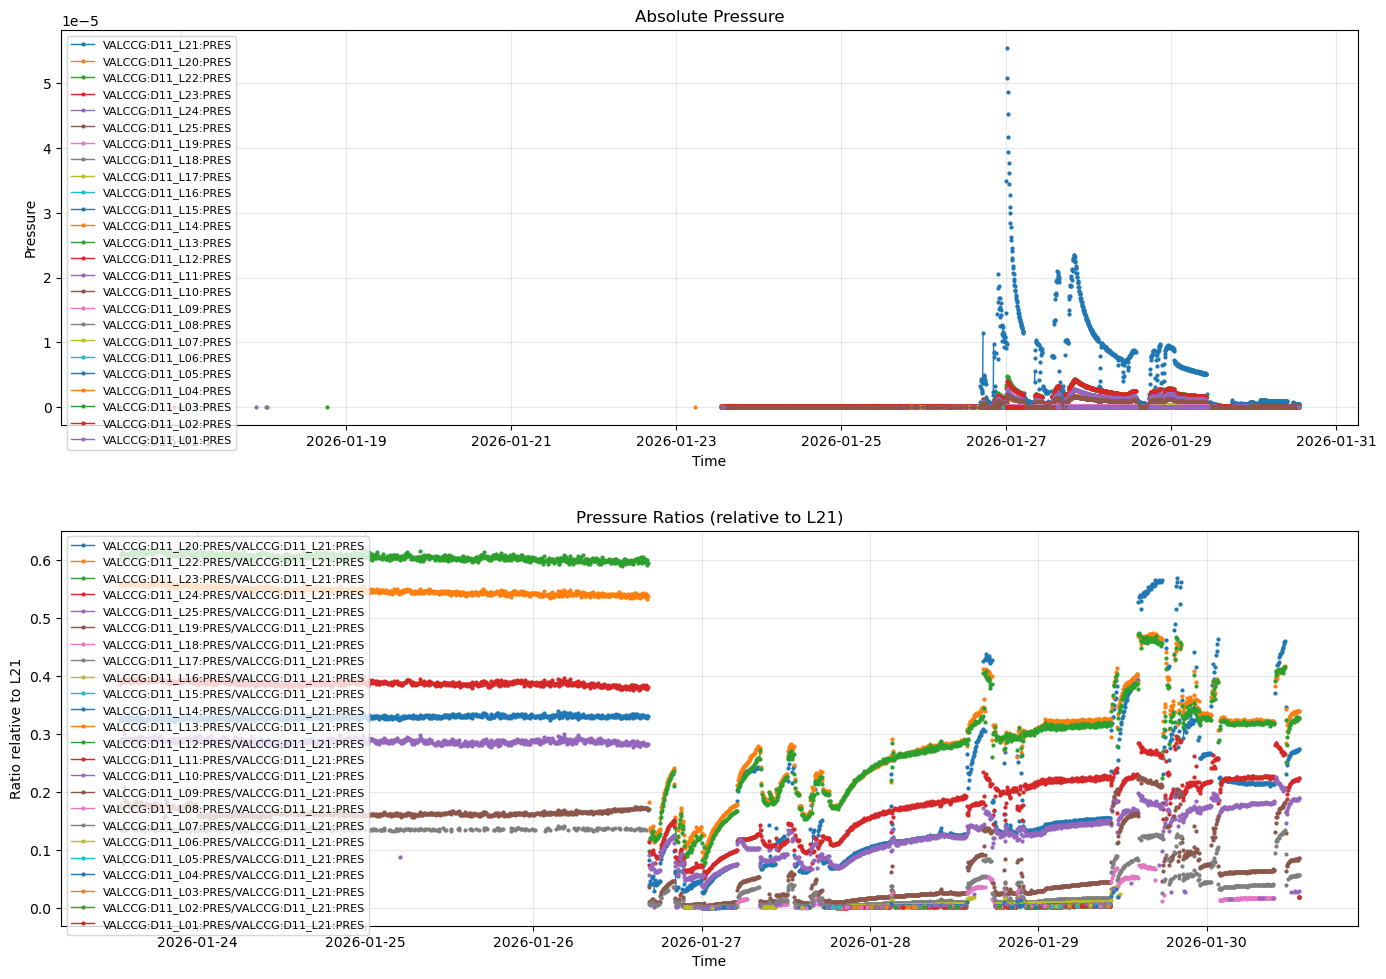

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the CSV file
vac = pd.read_csv('/Users/xylu/Desktop/Data/machine_local/vacuum_D11/2026-01-30T13_37_05.960Z.csv')

# Assuming the first column is time and the rest are channels
time_col = vac.columns[0]
channel_cols = vac.columns[1:]

# Convert time column to datetime
vac[time_col] = pd.to_datetime(vac[time_col])

# Check for NaN values
print(f"\nNaN values per column:")
print(vac.isna().sum())

# Find the L21 column (reference channel)
l21_col = [col for col in channel_cols if '_L21:' in col][0]
print(f"\nReference channel: {l21_col}")

# Calculate ratios relative to L21
ratio_data = {}
for channel in channel_cols:
    ratio_data[channel] = vac[channel] / vac[l21_col]
    print(f"{channel} / {l21_col}")

# Create two subplots - one for absolute values, one for ratios
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# Plot absolute pressure values
for channel in channel_cols:
    ax1.plot(vac[time_col], vac[channel], linewidth=1, label=channel, marker='o', markersize=2)

ax1.set_xlabel('Time')
ax1.set_ylabel('Pressure')
ax1.legend(loc='upper left', fontsize=8)
ax1.grid(True, alpha=0.3)
ax1.set_title('Absolute Pressure')

# Plot ratios relative to L21
for channel in channel_cols:
    if channel != l21_col:  # Don't plot L21/L21 (which is always 1)
        ax2.plot(vac[time_col], ratio_data[channel], linewidth=1, label=f"{channel}/{l21_col}", marker='o', markersize=2)

ax2.set_xlabel('Time')
ax2.set_ylabel('Ratio relative to L21')
ax2.legend(loc='upper left', fontsize=8)
ax2.grid(True, alpha=0.3)
ax2.set_title('Pressure Ratios (relative to L21)')

plt.tight_layout()
plt.show()